# explore() — validation and behaviour

Technical companion to the operation manual (`liveDemoIS.ipynb`). Where the manual shows
*how to use* `explore()`, this notebook documents *how it was validated and how it behaves*:

- **Part 1 — fidelity against MATLAB.** A model that MATLAB's `buildIS` already trained is loaded
  from its exported artifacts, and `explore()` is run on unseen test instances stage by stage —
  PRELIM, SIFTED, PILOT, PYTHIA, TRACE — with each stage's output compared against MATLAB's.
  Because both the model *and* the projected coordinates come from MATLAB, this isolates the Python
  inference code inside MATLAB's exact instance space, which is why the agreement is exact
  (0 % error / 100 % / $|r| = 1$).
- **Part 2 — a from-scratch Python build.** The same dataset is trained end to end with the Python
  `build()`, and `explore()` is shown to run on that model automatically and reproduce its own
  predictions. This is a self-contained Python model, so it is *not* compared to MATLAB — that
  comparison only makes sense against MATLAB's own model, which is what Part 1 does.

The trial dataset is machine-learning classification metadata: 212 training instances, 235 test
instances, 10 features, 10 algorithms. MATLAB's trained artifacts live under
`tests/matlab_reference/training_artifacts/` and its reference outputs under
`tests/matlab_reference/explore_outputs/`.

Run this notebook from the repository root.

In [1]:
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import MultiPolygon, Point, Polygon

from instancespace.data.model import PrelimOut, SiftedOut
from instancespace.instance_space import InstanceSpace

REFERENCE_DIR = Path("tests/matlab_reference")
ARTIFACTS_DIR = REFERENCE_DIR / "training_artifacts"
OUTPUTS_DIR = REFERENCE_DIR / "explore_outputs"
INPUT_DIR = REFERENCE_DIR / "input"

# Part 1 — How the validation numbers were obtained

## Loading the trained model

Each `explore()` stage consumes the artifacts that MATLAB's `buildIS` learned at training time:

| Stage  | Artifact | Role |
|--------|----------|------|
| PRELIM | `prelim/prelim_params.csv` | outlier bounds, Box-Cox $\lambda$, z-score $\mu$/$\sigma$ per feature |
| SIFTED | `sifted/sifted_indices.csv` | indices of the selected features |
| PILOT  | `pilot/pilot_matrix.csv` | the $2 \times n$ projection matrix $A$ |
| PYTHIA | `pythia/precision.csv`, `pythia/svm_<algo>.csv` | selection weights, per-algorithm SVMs (coordinate normalisation is derived from the training PILOT projection, not a separately stored constant) |
| TRACE  | `trace/good_<algo>.csv`, `trace/best_<algo>.csv` | trained footprint polygons |

The loaders below are the same ones used by the validation suite in `tests/exploreIS/`. The stage
methods `InstanceSpace._explore_<stage>` are driven directly with a model namespace assembled from
these artifacts — the same invocation pattern as the validation tests. (Driving the stage methods
directly, rather than through the public `explore()` entry point, is deliberate: it lets each
stage's output be compared against MATLAB's in isolation. The public `explore()` call is
demonstrated in Part 2.)

In [2]:
prelim_df = pd.read_csv(ARTIFACTS_DIR / "prelim" / "prelim_params.csv")
prelim = PrelimOut(
    med_val=np.zeros(len(prelim_df)),
    iq_range=np.zeros(len(prelim_df)),
    hi_bound=prelim_df["hi_bound"].to_numpy(),
    lo_bound=prelim_df["lo_bound"].to_numpy(),
    min_x=prelim_df["min_x"].to_numpy(),
    lambda_x=prelim_df["lambda_x"].to_numpy(),
    mu_x=prelim_df["mu_x"].to_numpy(),
    sigma_x=prelim_df["sigma_x"].to_numpy(),
    min_y=0.0,
    lambda_y=np.array([]),
    sigma_y=np.array([]),
    mu_y=np.array([]),
)

sifted_df = pd.read_csv(ARTIFACTS_DIR / "sifted" / "sifted_indices.csv")
selvars = (sifted_df["original_index"].to_numpy(dtype=np.intc) - 1).astype(np.intc)
sifted = SiftedOut(
    selvars=selvars, rho=None, pval=None, silhouette_scores=None, clust=None
)

pilot_df = pd.read_csv(ARTIFACTS_DIR / "pilot" / "pilot_matrix.csv")
# `z` (the training PILOT projection) is filled in once it's computed below -- PYTHIA's
# z-score normalisation is derived from it, not from a separately stored mu/sigma.
pilot = SimpleNamespace(
    a=pilot_df[["z1_coef", "z2_coef"]].to_numpy(dtype=np.double).T, z=None
)


class MatlabArtifactSvm:
    """A MATLAB-exported SVM artifact, callable like a fitted scikit-learn SVC.

    Post-S1, ``InstanceSpace._explore_pythia`` calls each stored model's own
    ``predict``/``predict_proba``, the same way it would call a real ``SVC`` -- this class
    implements just enough of that interface, using the kernel-evaluation + Platt-sigmoid
    math MATLAB's exported numbers (signed alphas, bias, kernel params, Platt A/B) require.
    Same shim used by ``tests/exploreIS/pythia/test_pythia_validation.py``.
    """

    classes_ = np.array([False, True])

    def __init__(
        self, support_vectors, alphas, bias, kernel_fn, kernel_param, platt_a, platt_b
    ):
        self.support_vectors = support_vectors
        self.alphas = alphas
        self.bias = bias
        self.kernel_fn = kernel_fn
        self.kernel_param = kernel_param
        self.platt_a = platt_a
        self.platt_b = platt_b

    def _post_good(self, z_norm):
        svs = self.support_vectors
        kernel_fn = self.kernel_fn.lower()
        if kernel_fn in ("gaussian", "rbf"):
            scale = self.kernel_param
            dist_sq = (
                np.sum(z_norm**2, axis=1, keepdims=True)
                + np.sum(svs**2, axis=1)
                - 2.0 * (z_norm @ svs.T)
            )
            k = np.exp(-dist_sq / scale**2)
        elif kernel_fn == "polynomial":
            k = (z_norm @ svs.T + 1.0) ** self.kernel_param
        else:
            k = z_norm @ svs.T
        decision = k @ self.alphas + self.bias
        return 1.0 / (1.0 + np.exp(self.platt_a * decision + self.platt_b))

    def predict_proba(self, z_norm):
        """Return [P(bad), P(good)] columns, matching sklearn's classes_ order."""
        post_good = self._post_good(z_norm)
        return np.column_stack([1.0 - post_good, post_good])

    def predict(self, z_norm):
        """Return the predicted class, matching sklearn's >=0.5 threshold."""
        return self._post_good(z_norm) >= 0.5


def load_svm(path: Path) -> MatlabArtifactSvm:
    """Reconstruct a per-algorithm SVM from its CSV.

    Each row is one support vector; row-1 columns also carry the per-SVM
    scalars (kernel_fn, kernel_param, bias, Platt A/B). Alphas are already
    signed (Alpha * SupportVectorLabels) on export.
    """
    df = pd.read_csv(path)
    return MatlabArtifactSvm(
        support_vectors=df[["sv_z1", "sv_z2"]].to_numpy(dtype=np.double),
        alphas=df["alpha"].to_numpy(dtype=np.double),
        kernel_fn=df["kernel_fn"].iloc[0],
        kernel_param=float(df["kernel_param"].iloc[0]),
        bias=float(df["bias"].iloc[0]),
        platt_a=float(df["platt_A"].iloc[0]),
        platt_b=float(df["platt_B"].iloc[0]),
    )


precision_df = pd.read_csv(ARTIFACTS_DIR / "pythia" / "precision.csv")
ALGO_ORDER = precision_df["algo"].tolist()
pythia = SimpleNamespace(
    precision=precision_df["precision"].to_numpy(dtype=np.double),
    svm=[load_svm(ARTIFACTS_DIR / "pythia" / f"svm_{algo}.csv") for algo in ALGO_ORDER],
)


def load_polygon(path: Path) -> Polygon | MultiPolygon | None:
    """Reconstruct a shapely (Multi)Polygon from a MATLAB polyshape CSV.

    MATLAB exports multi-region polyshapes as a single CSV with NaN rows
    delimiting the regions. A missing file is an empty footprint.
    """
    if not path.exists():
        return None
    vertices = pd.read_csv(path)[["x", "y"]].to_numpy(dtype=np.double)
    regions = []
    current = []
    for row in vertices:
        if np.isnan(row).any():
            if len(current) >= 3:
                regions.append(Polygon(current))
            current = []
        else:
            current.append(tuple(row))
    if len(current) >= 3:
        regions.append(Polygon(current))
    if not regions:
        return None
    return regions[0] if len(regions) == 1 else MultiPolygon(regions)


trace = SimpleNamespace(
    good=[
        SimpleNamespace(
            polygon=load_polygon(ARTIFACTS_DIR / "trace" / f"good_{algo}.csv")
        )
        for algo in ALGO_ORDER
    ],
    best=[
        SimpleNamespace(
            polygon=load_polygon(ARTIFACTS_DIR / "trace" / f"best_{algo}.csv")
        )
        for algo in ALGO_ORDER
    ],
)

model = SimpleNamespace(
    prelim=prelim, sifted=sifted, pilot=pilot, pythia=pythia, trace=trace
)
instance_space = SimpleNamespace(_model=model, _require_model=lambda: model)

non_empty_best = [a for a, fp in zip(ALGO_ORDER, trace.best) if fp.polygon is not None]
print(f"{len(ALGO_ORDER)} algorithms: {', '.join(ALGO_ORDER)}")
print(
    f"Good footprints: {sum(fp.polygon is not None for fp in trace.good)}/{len(ALGO_ORDER)}, "
    f"best footprints: {len(non_empty_best)}/{len(ALGO_ORDER)} "
    f"(non-empty: {', '.join(non_empty_best)})"
)

10 algorithms: NB, LDA, QDA, CART, J48, KNN, L_SVM, poly_SVM, RBF_SVM, RandF
Good footprints: 10/10, best footprints: 1/10 (non-empty: CART)


## Setting up the test data

The test set uses the same metadata format as training (see the repository README): an
`Instances` identifier column, `feature_` columns and `algo_` columns. Only the features are
needed for inference; the algorithm performance columns exist in this trial file but play no
role in the pipeline below.

In [3]:
test_metadata = pd.read_csv(INPUT_DIR / "metadata_test.csv")
feature_columns = [c for c in test_metadata.columns if c.startswith("feature_")]
x_raw = test_metadata[feature_columns].to_numpy(dtype=np.double)
instance_labels = test_metadata["Instances"]

print(f"{len(test_metadata)} test instances, {len(feature_columns)} features")
test_metadata.head()

235 test instances, 10 features


,Instances,feature_Max_Normalized_Entropy_attributes,feature_Normalized_Entropy_Class_Attribute,feature_Mean_Mutual_Information_Attribute_Class,feature_ErrorRate_Decision_Node,feature_WeightedDist_StdDev,feature_Max_Feature_Efficiency_F3,feature_Collective_Feature_Efficiency_F4,feature_Training_Error_Linear_Classifier_L2,feature_Fraction_Points_Class_Boundary_N1,...,algo_NB,algo_LDA,algo_QDA,algo_CART,algo_J48,algo_KNN,algo_L_SVM,algo_poly_SVM,algo_RBF_SVM,algo_RandF
0,abalone,0.332548,0.131687,0.229928,0.386459,2.343235,0.076929,0.095204,0.260235,0.404836,...,0.280096,0.239715,0.254012,0.245339,0.256491,0.256969,0.230584,0.277411,0.221198,0.234432
1,abalone_ori,0.332548,0.299462,0.368704,0.210410,2.343235,0.500693,0.555474,0.035714,0.082629,...,0.164182,0.159577,0.895472,0.172975,0.165282,0.167113,0.171518,0.178773,0.169919,0.895472
2,appendicitis,0.297231,0.106740,0.105274,0.141818,0.745009,0.292453,0.754717,0.198113,0.292453,...,0.141818,0.123636,0.170000,0.162727,0.132727,0.178182,0.123636,0.123636,0.132727,0.132727
3,asbestos,0.313965,0.202552,0.146191,0.219275,0.814613,0.134146,0.134146,0.154472,0.357724,...,0.253286,0.264329,0.554844,0.264329,0.264329,0.246951,0.264329,0.229573,0.231402,0.244275
4,audiology_std,0.279463,0.437579,0.100076,0.240355,0.690097,0.827618,0.966261,0.031711,0.041482,...,0.034967,0.859129,0.859129,0.060208,0.038009,0.072298,0.035244,0.265880,0.151676,0.859129


## PRELIM: bounding and scaling the test data

PRELIM re-applies the data preparation that was fitted at build time, with no re-estimation:
each feature is clipped to the training outlier bounds (median ± 5·IQR), shifted to a positive
range, Box-Cox transformed with the stored $\lambda$, and z-scored with the stored $\mu$ and
$\sigma$ (the "Auto-pre-processing" block of MATLAB `exploreIS.m`).

In [4]:
x_prelim = InstanceSpace._explore_prelim(instance_space, x_raw)

step1 = pd.read_csv(OUTPUTS_DIR / "step1_after_prelim.csv", index_col="instance_id")
prelim_err = np.abs(x_prelim - step1.to_numpy()) / (np.abs(step1.to_numpy()) + 1e-12)
print(f"Max relative error vs MATLAB step 1:  {prelim_err.max():.6%}")
print(f"Mean relative error vs MATLAB step 1: {prelim_err.mean():.6%}")

pd.DataFrame(x_prelim, index=instance_labels, columns=step1.columns).head()

2026-07-28 05:52:20.207 | WARNING  | instancespace.instance_space:_explore_prelim:603 - explore(): 9.8% of test instances have at least one feature outside the training bounds and were clipped to them. This suggests the test set may not be well represented by the trained instance space; consider retraining with a combined dataset.


Max relative error vs MATLAB step 1:  0.000000%
Mean relative error vs MATLAB step 1: 0.000000%


,Max_Normalized_Entropy_attributes,Normalized_Entropy_Class_Attribute,Mean_Mutual_Information_Attribute_Class,ErrorRate_Decision_Node,WeightedDist_StdDev,Max_Feature_Efficiency_F3,Collective_Feature_Efficiency_F4,Training_Error_Linear_Classifier_L2,Fraction_Points_Class_Boundary_N1,Nonlinearity_Nearest_Neighbor_Classifier_N4
Instances,,,,,,,,,,
abalone,0.295956,-0.057217,0.886483,1.233727,0.708027,-0.892574,-1.254885,1.055548,1.134618,1.275136
abalone_ori,0.295956,1.295543,1.398411,-0.135799,0.708027,0.854621,-0.120492,-1.163496,-0.795848,1.460828
appendicitis,-0.502396,-0.381586,-0.006613,-0.719773,-0.701276,0.171937,0.425788,0.600559,0.604311,0.460399
asbestos,-0.128526,0.657416,0.354321,-0.062564,-0.601823,-0.561026,-1.166366,0.220545,0.926423,1.018685
audiology_std,-0.890739,1.820903,-0.058625,0.109614,-0.784149,1.554180,1.038919,-1.221553,-1.160483,-1.239134


## SIFTED: applying the trained feature selection

SIFTED at explore time is pure indexing: the feature columns selected at build time are kept, in
the stored order. For the trial dataset all 10 features were kept, so the selection is the
identity here; on other datasets this is where the feature set shrinks.

From this stage on, every stage consumes the previous Python stage's output, so the comparisons
against MATLAB measure the accumulated end-to-end deviation. The isolated per-stage checks —
each stage fed with MATLAB's own inputs — live in `tests/exploreIS/`.

In [5]:
x_sifted = InstanceSpace._explore_sifted(instance_space, x_prelim)

step2 = pd.read_csv(
    OUTPUTS_DIR / "step2_after_sifted.csv", index_col="instance_id"
).to_numpy()
sifted_err = np.abs(x_sifted - step2) / (np.abs(step2) + 1e-12)
print(f"Selected {x_sifted.shape[1]} of {x_prelim.shape[1]} features")
print(f"Max relative error vs MATLAB step 2: {sifted_err.max():.6%}")

Selected 10 of 10 features
Max relative error vs MATLAB step 2: 0.000000%


## PILOT: projecting the data

The projection is a single matrix product with the trained matrix $A$: $Z = X A^{\top}$
(MATLAB `exploreIS.m`: `out.pilot.Z = out.data.X*model.pilot.A';`).

As in the MATLAB live demo, the training instances are drawn in grey underneath the test
instances. Their coordinates are obtained by pushing the training metadata through the same three
stages: the stored parameters were estimated on exactly these instances at build time, so this
reproduces the training coordinates `model.pilot.Z` that MATLAB's plots use as background.

2026-07-28 05:52:20.252 | WARNING  | instancespace.instance_space:_explore_prelim:603 - explore(): 10.4% of test instances have at least one feature outside the training bounds and were clipped to them. This suggests the test set may not be well represented by the trained instance space; consider retraining with a combined dataset.


Max relative error vs MATLAB step 3: 0.000000%


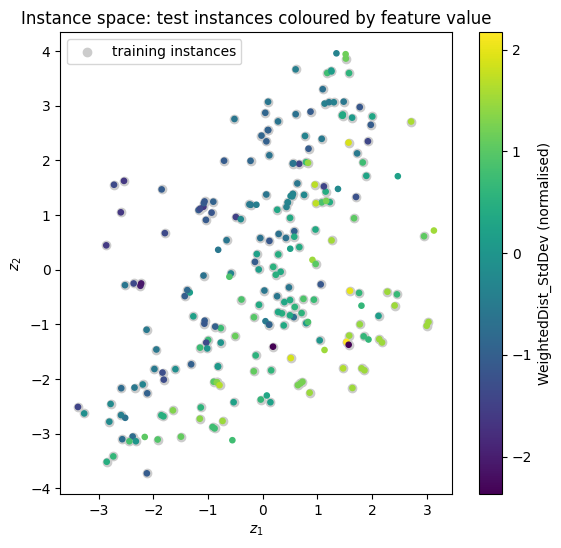

In [6]:
z_test = InstanceSpace._explore_pilot(instance_space, x_sifted)

train_metadata = pd.read_csv(INPUT_DIR / "metadata.csv")
x_train_raw = train_metadata[feature_columns].to_numpy(dtype=np.double)
z_train = InstanceSpace._explore_pilot(
    instance_space,
    InstanceSpace._explore_sifted(
        instance_space,
        InstanceSpace._explore_prelim(instance_space, x_train_raw),
    ),
)

step3 = pd.read_csv(
    OUTPUTS_DIR / "step3_after_pilot.csv", index_col="instance_id"
).to_numpy()
pilot_err = np.abs(z_test - step3) / (np.abs(step3) + 1e-12)
print(f"Max relative error vs MATLAB step 3: {pilot_err.max():.6%}")

selected_features = sifted_df["feature_name"].tolist()
ifeat = selected_features.index("WeightedDist_StdDev")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(z_train[:, 0], z_train[:, 1], c="0.8", s=36, label="training instances")
sc = ax.scatter(z_test[:, 0], z_test[:, 1], c=x_sifted[:, ifeat], cmap="viridis", s=14)
fig.colorbar(sc, ax=ax, label="WeightedDist_StdDev (normalised)")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title("Instance space: test instances coloured by feature value")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.show()

# PYTHIA's z-score normalisation (cell below) is derived from the training PILOT
# projection, not a separately stored constant -- wire it in now that it's computed.
pilot.z = z_train

## PYTHIA: testing the algorithm selection oracle

PYTHIA z-scores the coordinates using the mean/std of the training PILOT projection (not a separately stored constant -- see `InstanceSpace._explore_pythia`'s docstring for why), evaluates each algorithm's
trained SVM (Gaussian kernel exactly as MATLAB's `fitcsvm` defines it,
$K(x,y) = e^{-\lVert x-y \rVert^2 / s^2}$), and converts decision values into posterior
probabilities with the stored Platt coefficients. An instance's recommended algorithm
(`selection0`) is the precision-weighted argmax over the algorithms predicted good, or none (−1)
when no algorithm is predicted good (MATLAB `PYTHIAtest.m`).

In [7]:
y_hat, pr0_hat, selection0 = InstanceSpace._explore_pythia(instance_space, z_test)

step4_pred = pd.read_csv(
    OUTPUTS_DIR / "step4_pythia_predictions.csv",
    index_col="instance_id",
)[ALGO_ORDER].to_numpy(dtype=np.bool_)
step4_prob = pd.read_csv(
    OUTPUTS_DIR / "step4_pythia_probabilities.csv",
    index_col="instance_id",
)[ALGO_ORDER].to_numpy(dtype=np.double)

pythia_agreement = (y_hat == step4_pred).mean()
per_algo_r = [
    np.corrcoef(pr0_hat[:, j], step4_prob[:, j])[0, 1] for j in range(len(ALGO_ORDER))
]

pythia_summary = pd.DataFrame(
    {
        "predicted_good": y_hat.sum(axis=0),
        "recommended": [(selection0 == j).sum() for j in range(len(ALGO_ORDER))],
        "agreement_vs_matlab": (y_hat == step4_pred).mean(axis=0),
        "probability_pearson_r": per_algo_r,
    },
    index=ALGO_ORDER,
)
print(f"Binary prediction agreement vs MATLAB step 4: {pythia_agreement:.2%}")
print(f"Mean probability |r| vs MATLAB step 4: {np.mean(np.abs(per_algo_r)):.4f}")
print(
    f"Instances with no algorithm predicted good: {(selection0 == -1).sum()} of {len(selection0)}"
)
pythia_summary

Binary prediction agreement vs MATLAB step 4: 100.00%
Mean probability |r| vs MATLAB step 4: 1.0000
Instances with no algorithm predicted good: 55 of 235


,predicted_good,recommended,agreement_vs_matlab,probability_pearson_r
NB,146,0,1.0,1.0
LDA,159,0,1.0,1.0
QDA,83,0,1.0,1.0
CART,169,169,1.0,1.0
J48,176,5,1.0,1.0
KNN,176,0,1.0,1.0
L_SVM,172,2,1.0,1.0
poly_SVM,133,0,1.0,1.0
RBF_SVM,170,4,1.0,1.0
RandF,171,0,1.0,1.0


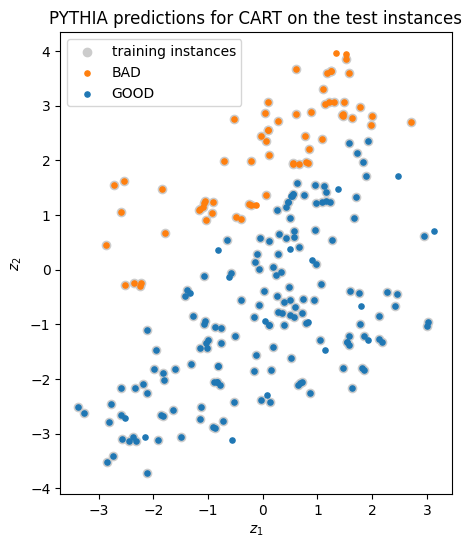

In [8]:
algo = "CART"
j = ALGO_ORDER.index(algo)
good = y_hat[:, j]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(z_train[:, 0], z_train[:, 1], c="0.8", s=36, label="training instances")
ax.scatter(z_test[~good, 0], z_test[~good, 1], c="tab:orange", s=14, label="BAD")
ax.scatter(z_test[good, 0], z_test[good, 1], c="tab:blue", s=14, label="GOOD")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title(f"PYTHIA predictions for {algo} on the test instances")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.show()

## TRACE: testing the footprints

TRACE at explore time checks footprint membership: for each algorithm, is a test instance inside
the *good* footprint (the region where good performance is statistically expected) and inside the
*best* footprint (the region where the algorithm is expected to dominate)? The polygons are the
trained `model.trace` polyshapes; membership uses shapely's boundary-inclusive `covers`, matching
MATLAB's `inpolygon`. In this trained model only CART has a non-empty best footprint — a missing
`best_<algo>.csv` is an empty footprint, and its column stays all-False.

In [9]:
in_good, in_best = InstanceSpace._explore_trace(instance_space, z_test)

step5 = pd.read_csv(OUTPUTS_DIR / "step5_trace_membership.csv", index_col="instance_id")
good_agreement = [
    (in_good[:, j] == step5[f"in_good_{a}"].to_numpy(dtype=np.bool_)).mean()
    for j, a in enumerate(ALGO_ORDER)
]
best_agreement = [
    (in_best[:, j] == step5[f"in_best_{a}"].to_numpy(dtype=np.bool_)).mean()
    for j, a in enumerate(ALGO_ORDER)
]
trace_agreement = np.mean(good_agreement + best_agreement)

trace_summary = pd.DataFrame(
    {
        "in_good": in_good.sum(axis=0),
        "in_best": in_best.sum(axis=0),
        "agreement_in_good": good_agreement,
        "agreement_in_best": best_agreement,
    },
    index=ALGO_ORDER,
)
print(f"Mean boolean agreement vs MATLAB step 5: {trace_agreement:.2%}")
trace_summary

Mean boolean agreement vs MATLAB step 5: 94.87%


,in_good,in_best,agreement_in_good,agreement_in_best
NB,112,0,0.919149,1.000000
LDA,129,0,0.919149,1.000000
QDA,54,0,0.931915,1.000000
CART,132,132,0.893617,0.893617
J48,136,0,0.902128,1.000000
KNN,138,0,0.906383,1.000000
L_SVM,138,0,0.906383,1.000000
poly_SVM,101,0,0.919149,1.000000
RBF_SVM,132,0,0.893617,1.000000
RandF,133,0,0.889362,1.000000


The end-to-end agreement is not 100% here, and every disagreement is the same degenerate case:
a test instance lying *exactly on a footprint boundary*. The trial test set re-uses all 212
training instances (plus 23 genuinely new ones), and the footprint polygons' vertices are training
coordinates — so those test points sit bit-exactly on the polygon boundary in MATLAB, where
`inpolygon` counts them as inside. The Python pipeline computes the coordinates independently, and
its values differ from MATLAB's at the $10^{-14}$ level (floating-point summation order), which is
enough to move a point that *is* a vertex to an epsilon outside of it.

The cell below verifies this: every disagreeing point is a re-used training instance sitting at
machine-precision distance from the footprint boundary, and on the genuinely unseen instances the
end-to-end agreement is exact. So is the agreement on MATLAB's own projected coordinates (see
`tests/exploreIS/trace/test_trace_validation.py`).

In [10]:
train_names = set(train_metadata["Instances"])
is_reused = test_metadata["Instances"].isin(train_names).to_numpy()
print(
    f"Test instances that are re-used training instances: {is_reused.sum()} of {len(is_reused)}"
)

disagreements = []
for j, a in enumerate(ALGO_ORDER):
    for kind, ours, poly in (
        ("good", in_good, trace.good[j].polygon),
        ("best", in_best, trace.best[j].polygon),
    ):
        ref = step5[f"in_{kind}_{a}"].to_numpy(dtype=np.bool_)
        for i in np.nonzero(ours[:, j] != ref)[0]:
            dist = poly.boundary.distance(Point(z_test[i, 0], z_test[i, 1]))
            disagreements.append((i, f"in_{kind}_{a}", dist))

print(f"Disagreeing (instance, column) pairs: {len(disagreements)}")
print(
    f"  all of them re-used training instances: "
    f"{all(is_reused[i] for i, _, _ in disagreements)}"
)
print(
    f"  max distance to the footprint boundary: "
    f"{max(d for _, _, d in disagreements):.3e}"
)

new_idx = ~is_reused
new_agreement = np.mean(
    [
        (
            in_good[new_idx, j]
            == step5[f"in_good_{a}"].to_numpy(dtype=np.bool_)[new_idx]
        ).mean()
        for j, a in enumerate(ALGO_ORDER)
    ]
    + [
        (
            in_best[new_idx, j]
            == step5[f"in_best_{a}"].to_numpy(dtype=np.bool_)[new_idx]
        ).mean()
        for j, a in enumerate(ALGO_ORDER)
    ],
)
print(f"Agreement on the {new_idx.sum()} genuinely new instances: {new_agreement:.2%}")

Test instances that are re-used training instances: 212 of 235
Disagreeing (instance, column) pairs: 241
  all of them re-used training instances: True
  max distance to the footprint boundary: 1.428e-14
Agreement on the 23 genuinely new instances: 100.00%


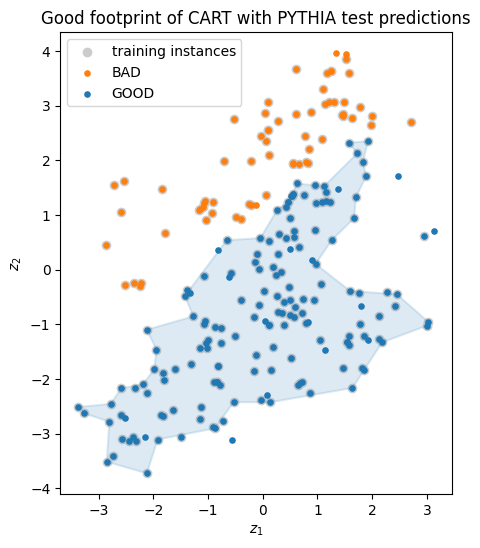

In [11]:
algo = "CART"
j = ALGO_ORDER.index(algo)
good = y_hat[:, j]
footprint = trace.good[j].polygon

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(z_train[:, 0], z_train[:, 1], c="0.8", s=36, label="training instances")
regions = footprint.geoms if isinstance(footprint, MultiPolygon) else [footprint]
for region in regions:
    xs, ys = region.exterior.xy
    ax.fill(
        xs, ys, facecolor="tab:blue", alpha=0.15, edgecolor="tab:blue", linewidth=1.5
    )
ax.scatter(z_test[~good, 0], z_test[~good, 1], c="tab:orange", s=14, label="BAD")
ax.scatter(z_test[good, 0], z_test[good, 1], c="tab:blue", s=14, label="GOOD")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title(f"Good footprint of {algo} with PYTHIA test predictions")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.show()

## Summary

End-to-end agreement between the Python `explore()` pipeline and the MATLAB reference on the
trial test set:

In [12]:
end_to_end = pd.DataFrame(
    {
        "comparison": [
            "max relative error",
            "max relative error",
            "max relative error",
            "binary agreement / mean probability |r|",
            "mean boolean agreement (all / unseen instances)",
        ],
        "observed": [
            f"{prelim_err.max():.6%}",
            f"{sifted_err.max():.6%}",
            f"{pilot_err.max():.6%}",
            f"{pythia_agreement:.2%} / {np.mean(np.abs(per_algo_r)):.4f}",
            f"{trace_agreement:.2%} / {new_agreement:.2%}",
        ],
    },
    index=["PRELIM", "SIFTED", "PILOT", "PYTHIA", "TRACE"],
)
end_to_end

,comparison,observed
PRELIM,max relative error,0.000000%
SIFTED,max relative error,0.000000%
PILOT,max relative error,0.000000%
PYTHIA,binary agreement / mean probability |r|,100.00% / 1.0000
TRACE,mean boolean agreement (all / unseen instances),94.87% / 100.00%


# Part 2 — Training and calling the pipeline from scratch in Python

Part 1 used a model that MATLAB trained. This part trains the *same* dataset end to end with the
Python `build()`, then shows how the pipeline is called and how much of a from-scratch Python run
feeds back into `explore()`.

`build()` runs the seven stages in dependency order — the Python equivalent of MATLAB
`buildIS.m`, which calls each stage in turn and stores the result on the model. There is no
separate "stage iterator": calling the stages in order *is* the build, exactly as in MATLAB.

| Python stage | MATLAB `buildIS.m` |
|--------------|--------------------|
| `PreprocessingStage` | data loading / `opts` setup |
| `PrelimStage` | `PRELIM` (line 139) |
| `SiftedStage` | `SIFTED` (line 228) |
| `PilotStage` | `PILOT` (line 264) |
| `CloisterStage` | `CLOISTER` (line 271) |
| `PythiaStage` | `PYTHIA` (line 281) |
| `TraceStage` | `TRACE` (line 290) |

The cell below makes the execution order explicit before running it.

In [13]:
import contextlib
import io
import time

from loguru import logger

from instancespace.data.metadata import from_csv_file
from instancespace.data.options import InstanceSpaceOptions
from instancespace.stages.preprocessing import PreprocessingStage
from instancespace.stages.prelim import PrelimStage
from instancespace.stages.sifted import SiftedStage
from instancespace.stages.pilot import PilotStage
from instancespace.stages.pythia import PythiaStage
from instancespace.stages.cloister import CloisterStage
from instancespace.stages.trace import TraceStage

train = from_csv_file(INPUT_DIR / "metadata.csv")
options = InstanceSpaceOptions.default(*([None] * 12))  # all stage defaults

build_stages = [
    PreprocessingStage,
    PrelimStage,
    SiftedStage,
    PilotStage,
    PythiaStage,
    CloisterStage,
    TraceStage,
]
trained = InstanceSpace(train, options, stages=build_stages)

print("build() runs these stages in dependency order:")
for i, group in enumerate(trained._runner._stage_order, 1):
    print(f"  {i}. {', '.join(s.__name__ for s in group)}")

# Training the full pipeline (per-algorithm SVM cross-validation + footprint
# construction) takes a few minutes on this dataset; its progress log is suppressed here.
t0 = time.time()
_sink = io.StringIO()
logger.disable("instancespace")
try:
    with contextlib.redirect_stdout(_sink), contextlib.redirect_stderr(_sink):
        built_model = trained.build()
finally:
    logger.enable("instancespace")
print(f"\nbuild() completed in {time.time() - t0:.0f}s")

build() runs these stages in dependency order:
  1. PreprocessingStage
  2. PrelimStage
  3. SiftedStage
  4. PilotStage
  5. CloisterStage, PythiaStage
  6. TraceStage



build() completed in 1031s


In [14]:
algo_summary = built_model.trace.summary.set_index("Algorithm")[["Area_Good"]].copy()
algo_summary["cv_accuracy"] = [round(float(a), 3) for a in built_model.pythia.accuracy]
algo_summary = algo_summary.rename(columns={"Area_Good": "good_footprint_area"})

n_feat_total = built_model.data.x_raw.shape[1]
n_feat_sifted = len(built_model.data.feat_labels)
print(f"PILOT projection matrix A: shape {np.asarray(built_model.pilot.a).shape}")
print(
    f"{len(built_model.data.algo_labels)} algorithms; "
    f"SIFTED kept {n_feat_sifted} of {n_feat_total} features "
    f"(MATLAB's reference run disabled SIFTED and kept all {n_feat_total})"
)
algo_summary

PILOT projection matrix A: shape (2, 6)
10 algorithms; SIFTED kept 6 of 10 features (MATLAB's reference run disabled SIFTED and kept all 10)


,good_footprint_area,cv_accuracy
Algorithm,,
NB,4.953881,0.821
LDA,5.267157,0.750
QDA,1.558156,0.745
CART,5.737132,0.858
J48,5.386088,0.863
KNN,5.968811,0.835
L_SVM,5.078470,0.877
poly_SVM,3.635626,0.821
RBF_SVM,5.700867,0.873


## `build()` and `explore()` share the same native model

`build()` and `explore()` operate on the same trained `Model`: each PYTHIA SVM is a fitted
scikit-learn `SVC`, and `explore()` calls that `SVC`'s own `predict`/`predict_proba` directly —
there is no intermediate flattened representation and no conversion step. PRELIM, SIFTED, PILOT,
and TRACE pass their stored parameters through unchanged; only PYTHIA needs any extra handling,
and that is limited to re-deriving the z-score normalisation constants from the trained PILOT
projection (`model.pilot.z`), since PYTHIA's own stored `mu`/`sigma` are statistics of its
already-normalised training data, not of the raw inputs `explore()` needs to normalise.

The inference stages themselves are untouched, so their validated 1:1 fidelity is preserved.


In [15]:
test_meta = from_csv_file(INPUT_DIR / "metadata_test.csv")
algo_labels = [a.replace("algo_", "") for a in built_model.data.algo_labels]

result = trained.explore(test_meta, dataset_id="from_scratch")

print(
    f"explore() returned: z {result.z.shape}, y_hat {result.y_hat.shape}, "
    f"in_good {result.in_good.shape}, in_best {result.in_best.shape}"
)

from_scratch = pd.DataFrame(
    {
        "predicted_good": result.y_hat.sum(axis=0),
        "recommended": [
            int((result.selection0 == j).sum()) for j in range(len(algo_labels))
        ],
    },
    index=algo_labels,
)
from_scratch

2026-07-28 06:09:32.621 | WARNING  | instancespace.instance_space:_explore_prelim:603 - explore(): 9.8% of test instances have at least one feature outside the training bounds and were clipped to them. This suggests the test set may not be well represented by the trained instance space; consider retraining with a combined dataset.


explore() returned: z (235, 2), y_hat (235, 10), in_good (235, 10), in_best (235, 10)


,predicted_good,recommended
NB,149,1
LDA,165,0
QDA,71,0
CART,184,1
J48,180,6
KNN,188,5
L_SVM,175,175
poly_SVM,122,0
RBF_SVM,182,3
RandF,185,1


## Verifying the from-scratch model is applied correctly

The model just trained in Python is a *different* model from MATLAB's. `build()` solves PILOT's
projection independently and lands in a different — but equally valid — instance space (the
objective has infinitely many equivalent optima, confirmed with the supervisor), so its
coordinates and the good/bad calls that follow are not expected to match MATLAB's. Comparing this
model's predictions to MATLAB's reference numbers would therefore measure how two independent
builds happen to differ, not the fidelity of `explore()` — which Part 1 already established
exactly, using MATLAB's own model. So no comparison to MATLAB is done here; it would not mean
anything.

The check that *is* meaningful is self-consistency: does `explore()` reproduce the predictions the
build itself made on its training instances? If so, `explore()` is applying the
Python-built model correctly.

In [16]:
# self-consistency: explore() reproduces the build model's OWN training predictions
yhat_train, _, _ = InstanceSpace._explore_pythia(trained, built_model.pilot.z)
self_consistency = (yhat_train == np.asarray(built_model.pythia.y_hat)).mean()

pd.DataFrame(
    {"agreement": [f"{self_consistency:.2%}"]},
    index=["explore() reproduces the trained model's own predictions"],
)

,agreement
explore() reproduces the trained model's own predictions,100.00%


The self-consistency is high, which confirms the adapter and `explore()` apply the Python-built
model correctly — the flattened SVMs reproduce the predictions the build made itself.

To summarise the two validation angles:

- **Feed MATLAB's own trained model** (Part 1) and the agreement with MATLAB's reference is exact.
  This is the 1:1 proof that the `explore()` port is faithful, and it is the only place a
  comparison to MATLAB is meaningful — same model, same instance space.
- **Train from scratch in Python** (Part 2) and the model is a different, equally valid one, so it
  is *not* compared to MATLAB; instead `explore()` is shown to reproduce that model's own
  predictions. This confirms the from-scratch build → `explore()` path works end to end.

### Scope notes

- This work is an inference-only port of `exploreIS.m`. Part 1 — MATLAB's `buildIS` trains the
  model, its parameters are exported, and Python's `explore()` consumes them with no stage
  re-fitted — is the validated, reproducible 1:1 result.
- Part 2 trains in Python and calls `explore()` directly on the resulting `Model` (see the
  repository README); the inference stages themselves are unchanged. A from-scratch Python build
  is a different, equally valid model, so it is not compared numerically to MATLAB — Part 2
  verifies self-consistency instead (`explore()` reproduces the build's own predictions).
- `step5_trace_membership.csv` also carries an `in_space` column; it comes from CLOISTER's
  correlation-based boundary, a build-time stage outside this port's scope, so it is not
  computed or compared here.

The per-stage validation suite — each stage additionally isolated by feeding it MATLAB's own
inputs, with thresholds and their rationale documented in each test — can be run directly:


In [17]:
import subprocess
import sys

completed = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/exploreIS/", "-q"],
    capture_output=True,
    text=True,
    check=False,
)
print(completed.stdout[-2000:])

...............................................                          [100%]
47 passed in 5.78s

